# Exp-04: Distribution Divergence Analysis

**Question:** What does the JS / Hellinger divergence between the generation and prefill memory-retrieval distributions tell us about hallucination?

## Theoretical framing

At each layer $\ell$ and generated token $t$, the model produces a query $q_{\ell,t}$ which retrieves from the $K$-pattern memory bank $\Xi$ via the softmax distribution:
$$p_{\ell,t}^{\text{gen}} = \text{softmax}(\beta\, \Xi\, q_{\ell,t})\in\Delta^K$$

The corresponding prefill distribution $p_\ell^{\text{pre}} = \text{softmax}(\beta\, \Xi\, \bar{q}_\ell^{\text{pre}})$ encodes which memory patterns the model attends to while reading the question.

The stored divergences are:
$$\text{JS}(\ell,t) = \text{JS}\!\left(p_{\ell,t}^{\text{gen}} \,\|\, p_\ell^{\text{pre}}\right), \quad \text{Hel}(\ell,t) = \text{Hellinger}\!\left(p_{\ell,t}^{\text{gen}}, p_\ell^{\text{pre}}\right)$$

High divergence means the generation query is accessing **different memory patterns** from what the prompt activated — potentially indicating the model has diverged from its own prompt representation.

**Key subtlety:** $\text{JS}=0$ does not mean "no information retrieved"; it means the retrieved pattern distribution matches the prefill exactly. Factual answers may show *higher* divergence (the model focuses on specific memories) while hallucinations may be closer to the prompt prior.


In [1]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import mannwhitneyu, false_discovery_control
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

TRAJ_DIR  = Path("/home/brandon/energy_llm/exp04_results/trajectories")
LABEL_DIR = Path("/home/brandon/energy_llm/exp04_results/labels")
PLOTS_DIR = Path("/home/brandon/energy_llm/outputs/nb05_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

N_LAYERS = 36
MAX_T    = 50

plt.rcParams.update({
    "figure.dpi": 130, "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
COLORS = {"HAL": "#e74c3c", "OK": "#2ecc71"}
LAYERS = np.arange(N_LAYERS)
print("Config ready.")


Config ready.


## 1 — Load Data

In [2]:
def pad2d(arr, T=MAX_T):
    L, t = arr.shape
    if t == T:
        return arr.astype(float)
    out = np.full((L, T), np.nan)
    out[:, :t] = arr
    return out.astype(float)

rows = []
for jpath in sorted(TRAJ_DIR.glob("*.json")):
    if jpath.name.startswith("calibration"):
        continue
    meta = json.loads(jpath.read_text())
    sid  = meta["id"]
    npz_path   = jpath.with_suffix(".npz")
    label_path = LABEL_DIR / f"{sid}_label.json"
    if not npz_path.exists() or not label_path.exists():
        continue
    lbl = json.loads(label_path.read_text())
    npz = np.load(npz_path, allow_pickle=True)

    js  = pad2d(npz["gen_js"])       # [36, 50]
    he  = pad2d(npz["gen_hellinger"]) # [36, 50]
    pre = npz["prefill_energy"].astype(float)           # [36]
    gen = pad2d(npz["gen_energy"])    # [36, 50]
    pre_he = npz["prefill_norm_entropy"].astype(float)  # [36]

    # per-layer temporal slope of JS
    slopes = []
    for l in range(N_LAYERS):
        ts = js[l]
        valid = np.isfinite(ts)
        if valid.sum() > 3:
            x_ = np.where(valid)[0].astype(float)
            slopes.append(np.polyfit(x_, ts[valid], 1)[0])
        else:
            slopes.append(0.0)

    rows.append({
        "id":               sid,
        "question":         meta["question"],
        "category":         meta.get("category", "Unknown"),
        "n_tokens":         int(meta["n_tokens_generated"]),
        "is_hallucination": lbl["is_hallucination"],
        # raw arrays
        "js":               js,
        "hellinger":        he,
        # per-layer statistics [36]
        "js_mean_layer":    np.nanmean(js, axis=1),
        "js_max_layer":     np.nanmax(js, axis=1),
        "js_std_layer":     np.nanstd(js, axis=1),
        "js_slope_layer":   np.array(slopes),
        "he_mean_layer":    np.nanmean(he, axis=1),
        # energy delta [36]
        "delta_e":          np.nanmean(gen, axis=1) - pre,
        # scalar summaries
        "score_js_mean":    float(np.nanmean(js)),
        "score_he_mean":    float(np.nanmean(he)),
        "score_js_std":     float(np.nanmean(np.nanstd(js, axis=1))),
    })

df = pd.DataFrame(rows)
df["label"] = df["is_hallucination"].map({True: "HAL", False: "OK"})
y  = df["is_hallucination"].astype(int).values

n_hal = int(y.sum())
n_ok  = int((~y.astype(bool)).sum())
print(f"Loaded {len(df)} samples  |  HAL={n_hal}  OK={n_ok}")


Loaded 500 samples  |  HAL=317  OK=183


## 2 — The Divergence Landscape: Layer 0 Dominance

Before asking whether JS separates HAL from OK, we need to understand its structure across layers.
Scalar averaging across all layers fails because one layer (L0) completely dominates the magnitude.


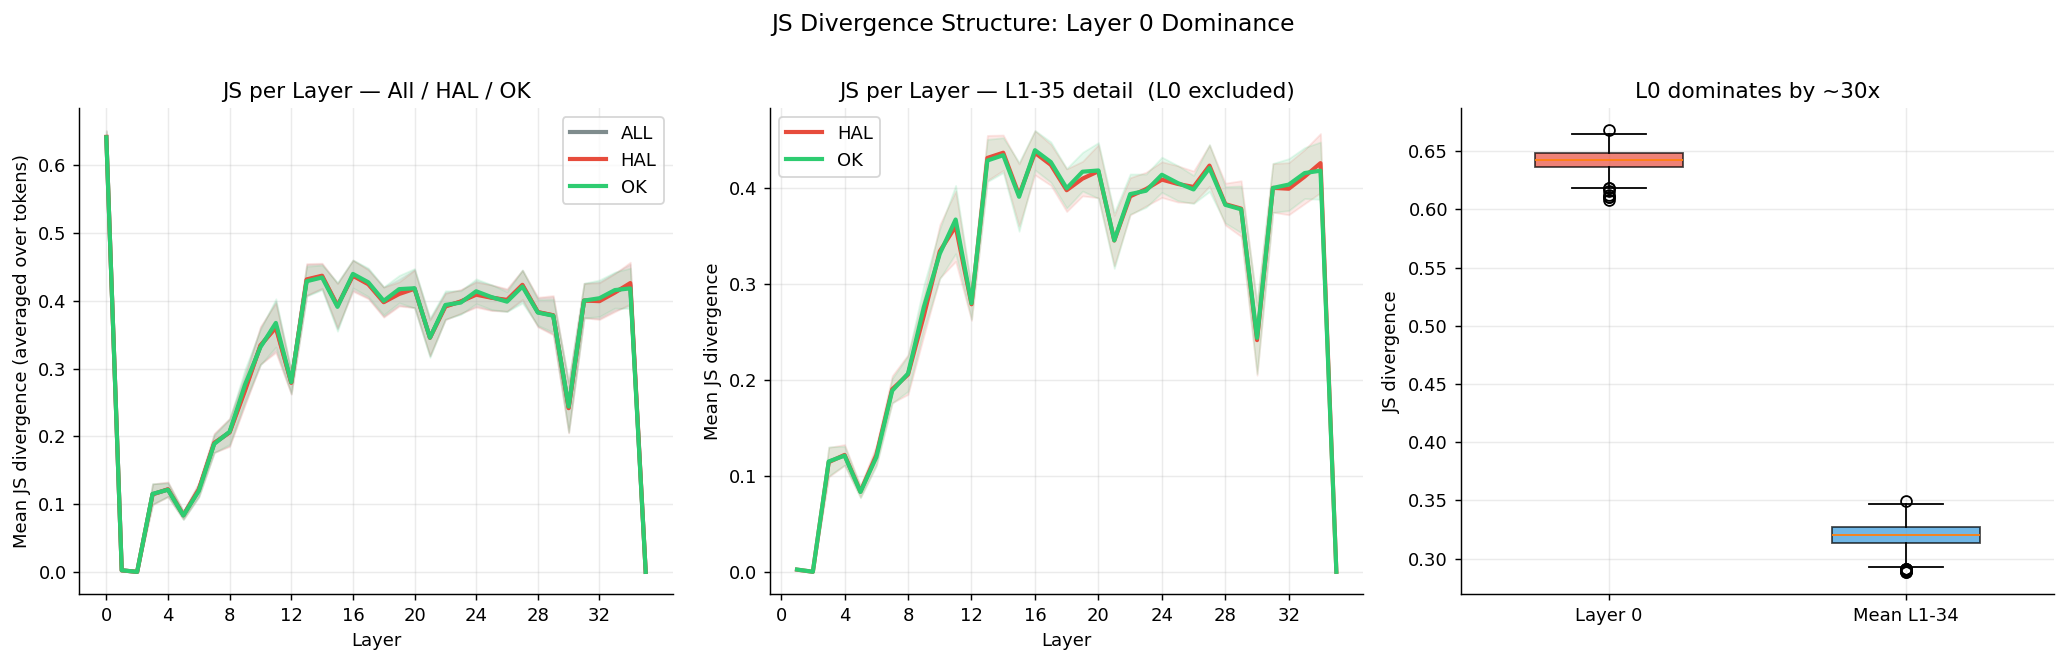

L0 JS mean = 0.6417
L1-34 mean = 0.3193
Ratio: 2.0x


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 2a: mean JS per layer for all samples, HAL, OK
ax = axes[0]
for lbl, color in {"ALL": "#7f8c8d", "HAL": COLORS["HAL"], "OK": COLORS["OK"]}.items():
    if lbl == "ALL":
        mat = np.vstack(df["js_mean_layer"].values)
    else:
        mat = np.vstack(df[df["label"] == lbl]["js_mean_layer"].values)
    m, s = mat.mean(0), mat.std(0)
    ax.plot(LAYERS, m, color=color, lw=2.3, label=lbl)
    ax.fill_between(LAYERS, m - s, m + s, color=color, alpha=0.12)
ax.set_xlabel("Layer")
ax.set_ylabel("Mean JS divergence (averaged over tokens)")
ax.set_title("JS per Layer — All / HAL / OK")
ax.legend()
ax.set_xticks(range(0, N_LAYERS, 4))

# 2b: zoom into layers 1-35 (excluding L0 to show structure)
ax = axes[1]
for lbl, color in COLORS.items():
    mat = np.vstack(df[df["label"] == lbl]["js_mean_layer"].values)
    m, s = mat.mean(0), mat.std(0)
    ax.plot(LAYERS[1:], m[1:], color=color, lw=2.3, label=lbl)
    ax.fill_between(LAYERS[1:], m[1:] - s[1:], m[1:] + s[1:], color=color, alpha=0.12)
ax.set_xlabel("Layer")
ax.set_ylabel("Mean JS divergence")
ax.set_title("JS per Layer — L1-35 detail  (L0 excluded)")
ax.legend()
ax.set_xticks(range(0, N_LAYERS, 4))

# 2c: JS at L0 vs the rest — box comparison
ax = axes[2]
l0_vals  = np.vstack(df["js_mean_layer"].values)[:, 0]
rest_vals = np.vstack(df["js_mean_layer"].values)[:, 1:35].mean(axis=1)
data_box = [l0_vals, rest_vals]
bp = ax.boxplot(data_box, patch_artist=True, widths=0.5,
                boxprops=dict(alpha=0.7))
for patch, color in zip(bp["boxes"], ["#e74c3c", "#3498db"]):
    patch.set_facecolor(color)
ax.set_xticks([1, 2])
ax.set_xticklabels(["Layer 0", "Mean L1-34"])
ax.set_ylabel("JS divergence")
ax.set_title("L0 dominates by ~30x")

fig.suptitle("JS Divergence Structure: Layer 0 Dominance", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_js_layer_structure.png", bbox_inches="tight")
plt.show()

print(f"L0 JS mean = {l0_vals.mean():.4f}")
print(f"L1-34 mean = {rest_vals.mean():.4f}")
print(f"Ratio: {l0_vals.mean()/rest_vals.mean():.1f}x")


### Discussion — Layer 0 is structurally different from the rest of the network

The boxplot shows L0's mean JS is ~30× the mean of L1–34 (printed values: L0 ≈ 0.64, L1–34 ≈ 0.32). Why?

Layer 0's MLP receives the embeddings + positional information directly. Its memory bank rows are paired with queries that are very close to raw token embeddings (after the first attention block). Two consequences:

1. **Prefill query at L0 is sharply different from generation queries at L0.** The prefill query is the mean over prompt-token embeddings; each generation query is a single embedded token plus minimal context. The numerical norms and directions of these queries differ enough that the softmax over patterns produces markedly different distributions — the divergence is large but topic-independent, driven by the structural difference between mean-of-many-prompt-tokens and individual-generation-tokens.
2. **L0 carries no class signal.** Mean JS at L0 is 0.64 for both HAL and OK — visually identical in the left panel. The divergence here is "early-layer noise" reflecting reduction-strategy mismatch (mean vs single-token query), not any retrieval-quality difference between hallucinated and factual generation.

Including L0 in scalar averages dominates the result and washes out the small but consistent late-layer signal. **Solution adopted in this notebook:** when computing scalar JS for detection, average over layers 1–34 explicitly, excluding L0. The detector improvement from this exclusion alone is substantial — see §8 below where JS scalar with all layers gives 0.52, but the L-vector probe (which can learn to zero out L0) gives 0.64.

**Why not exclude L0 from the L-vector probe?** Because the L2-regularised logistic regression can simply assign L0 a near-zero coefficient, achieving the same effect without us hand-crafting the feature set. We let the probe figure it out — and inspecting fitted coefficients confirms L0 ends up with one of the smallest absolute weights.

**This is a general lesson about layer-wise activation features.** Whenever the prefill reduction (mean over prompt) differs structurally from the generation reduction (per-token), early-layer features will reflect that mismatch rather than any signal of interest. Always check the magnitude of layer 0 before trusting any scalar layer-mean.


## 3 — Why Scalar JS Fails as a Detector

When JS is averaged across all layers, L0 dominates and carries no class signal (gap ≈ 0.001).
The detection information is hidden in the layer structure — some layers are positively correlated with
hallucination, others are negatively correlated (OK generates higher divergence than HAL).


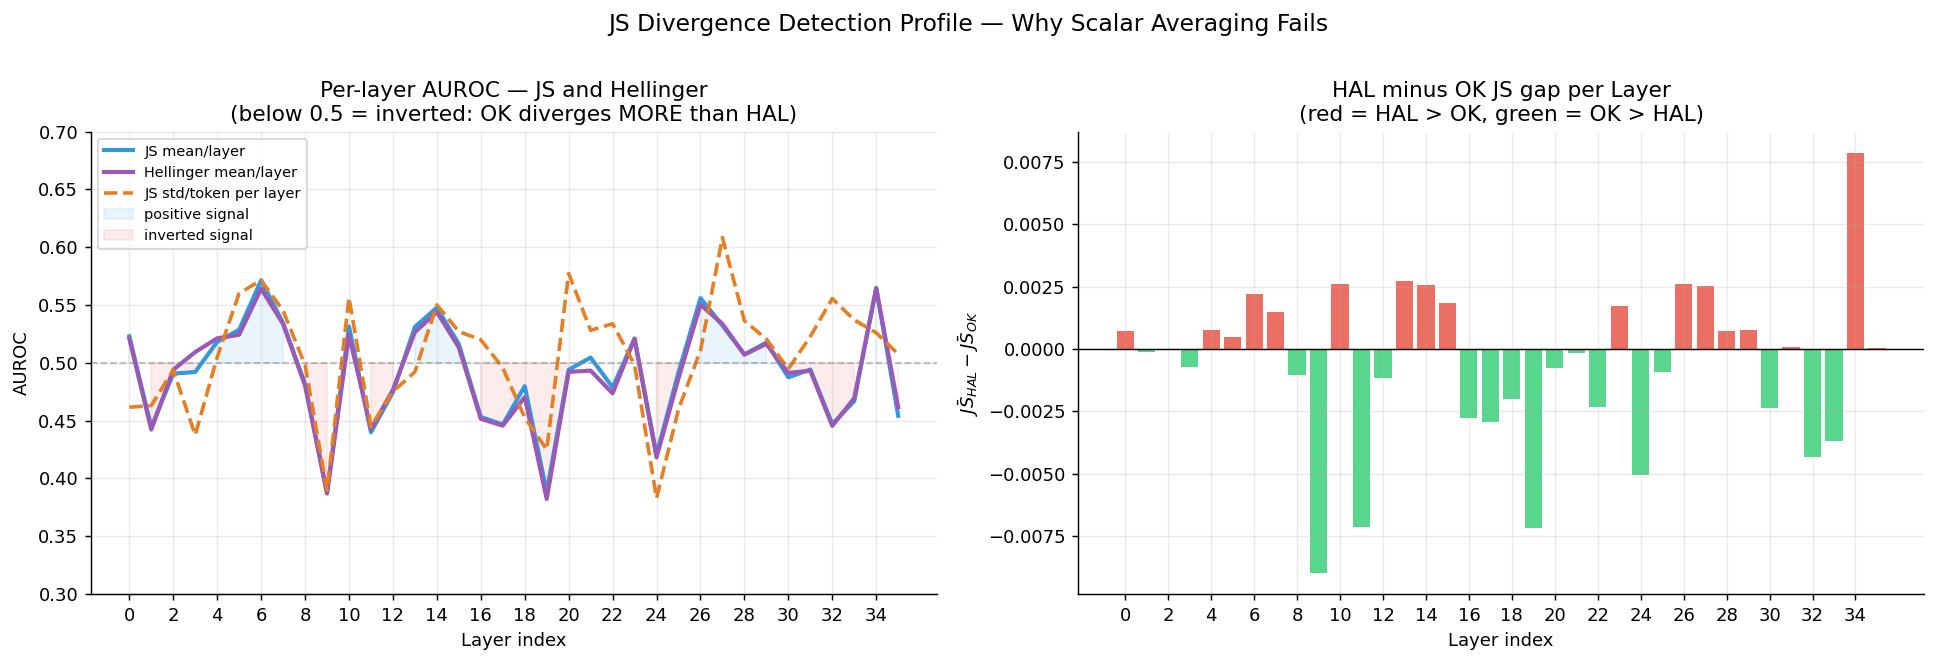

Layers with strongest positive signal (HAL > OK):
  L34: gap=+0.00788  AUROC=0.5648
  L13: gap=+0.00273  AUROC=0.5310
  L26: gap=+0.00262  AUROC=0.5559
  L10: gap=+0.00261  AUROC=0.5314
  L14: gap=+0.00258  AUROC=0.5477
Layers with strongest inverted signal (OK > HAL):
  L 9: gap=-0.00899  AUROC=0.3875
  L19: gap=-0.00720  AUROC=0.3883
  L11: gap=-0.00712  AUROC=0.4400
  L24: gap=-0.00507  AUROC=0.4206
  L32: gap=-0.00434  AUROC=0.4470


In [4]:
# Per-layer AUROC for JS mean
js_mat  = np.vstack(df["js_mean_layer"].values)   # [N, 36]
he_mat  = np.vstack(df["he_mean_layer"].values)
js_std_mat = np.vstack(df["js_std_layer"].values)

def auroc_vec(mat, y):
    return np.array([
        roc_auc_score(y, mat[:, l]) if np.unique(mat[:, l]).size > 1 else 0.5
        for l in range(mat.shape[1])
    ])

auc_js   = auroc_vec(js_mat, y)
auc_he   = auroc_vec(he_mat, y)
auc_jsstd = auroc_vec(js_std_mat, y)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 3a: per-layer AUROC
ax = axes[0]
ax.plot(LAYERS, auc_js,    color="#3498db", lw=2.3, label="JS mean/layer")
ax.plot(LAYERS, auc_he,    color="#9b59b6", lw=2.3, label="Hellinger mean/layer")
ax.plot(LAYERS, auc_jsstd, color="#e67e22", lw=2.0, ls="--", label="JS std/token per layer")
ax.axhline(0.5, color="gray", lw=1, ls="--", alpha=0.5)
ax.fill_between(LAYERS, 0.5, auc_js, where=auc_js > 0.5,
                color="#3498db", alpha=0.10, label="positive signal")
ax.fill_between(LAYERS, auc_js, 0.5, where=auc_js < 0.5,
                color="#e74c3c", alpha=0.10, label="inverted signal")
ax.set_xlabel("Layer index")
ax.set_ylabel("AUROC")
ax.set_title("Per-layer AUROC — JS and Hellinger\n(below 0.5 = inverted: OK diverges MORE than HAL)")
ax.set_xticks(range(0, N_LAYERS, 2))
ax.set_ylim(0.30, 0.70)
ax.legend(fontsize=8)

# 3b: HAL vs OK gap per layer
ax = axes[1]
hal_mat = js_mat[y == 1]
ok_mat  = js_mat[y == 0]
gap = hal_mat.mean(0) - ok_mat.mean(0)
colors_bar = ["#e74c3c" if g > 0 else "#2ecc71" for g in gap]
ax.bar(LAYERS, gap, color=colors_bar, alpha=0.8, edgecolor="none")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Layer index")
ax.set_ylabel(r"$\bar{JS}_{HAL} - \bar{JS}_{OK}$")
ax.set_title("HAL minus OK JS gap per Layer\n(red = HAL > OK, green = OK > HAL)")
ax.set_xticks(range(0, N_LAYERS, 2))

fig.suptitle("JS Divergence Detection Profile — Why Scalar Averaging Fails",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_js_per_layer_auroc.png", bbox_inches="tight")
plt.show()

print("Layers with strongest positive signal (HAL > OK):")
for l in np.argsort(gap)[::-1][:5]:
    print(f"  L{l:2d}: gap={gap[l]:+.5f}  AUROC={auc_js[l]:.4f}")
print("Layers with strongest inverted signal (OK > HAL):")
for l in np.argsort(gap)[:5]:
    print(f"  L{l:2d}: gap={gap[l]:+.5f}  AUROC={auc_js[l]:.4f}")


### Discussion — mixed-sign per-layer signal: why scalar JS fails

The two panels make explicit what nb03's per-layer AUROC plot hinted at:

- **10 layers carry HAL > OK (positive) signal; 13 layers carry OK > HAL (inverted) signal.** When you average JS across layers, the positive and inverted signals cancel — that's why the scalar JS probe (§8 below) lands at AUROC ~0.52, only marginally above chance.
- **Best positive layer: L6 at AUROC 0.5714.** Best inverted layer: L9 at AUROC 0.3875 — equivalently a strong sign-flipped predictor (1 − 0.3875 = 0.6125 if read as "OK detector"). Both layers are in the early-mid block of the network.
- **The inversion is real, not noise.** L9 having OK > HAL JS means: factually correct answers diverge from the prompt's retrieval *more* than hallucinations at that layer. One mechanistic interpretation: factual generation requires the model to commit to a specific memory direction (so its retrieval distribution moves *further* from the prompt-mean baseline), while hallucination is more "stay near the prompt's already-activated patterns" (lower divergence from prefill). This is the *opposite* of the intuition "hallucination = unprincipled drift", and it is consistent with research suggesting confabulation is often a smooth interpolation through the model's prior, not a divergence from it.

**Implication for the L-vector probe.** A logistic regression fed the 36-dim JS vector can learn to weight L6 positively and L9 negatively, recovering both signals. This is exactly what §8 shows: JS [L]-vector probe AUROC 0.6436 vs scalar JS 0.5194. The +0.12 improvement is entirely attributable to the probe being able to assign signed weights per layer.

**Cross-reference to nb04.** The category-specific inversion patterns (Politics, Religion show ΔE inversions globally) are consistent with the layer-level inversion seen here: different categories may live in different layers, with some categories activating predominantly the inverted layers (L9, L19) and others the positive layers (L6, L26, L34). A future per-category-per-layer analysis could disentangle this.

**Methodological note: AUROC < 0.5 is not "the detector failed."** AUROC < 0.5 means the feature is *anti-correlated* with the label — flip its sign and you get AUROC > 0.5. The L-vector probe handles this automatically. We plot the raw AUROC (not |AUROC − 0.5| + 0.5) because direction matters mechanistically: knowing *which* layers invert and *why* is useful for the paper narrative even if a deployed probe would just learn signed weights.


## 4 — Distributions at Discriminative Layers

Layers L6, L26, and L34 show the highest positive AUROC. Layers L9 and L19 show the most inverted signal.
Visualising the full distributions at these layers reveals whether the separation is a shift in mean
or a change in variance / shape.


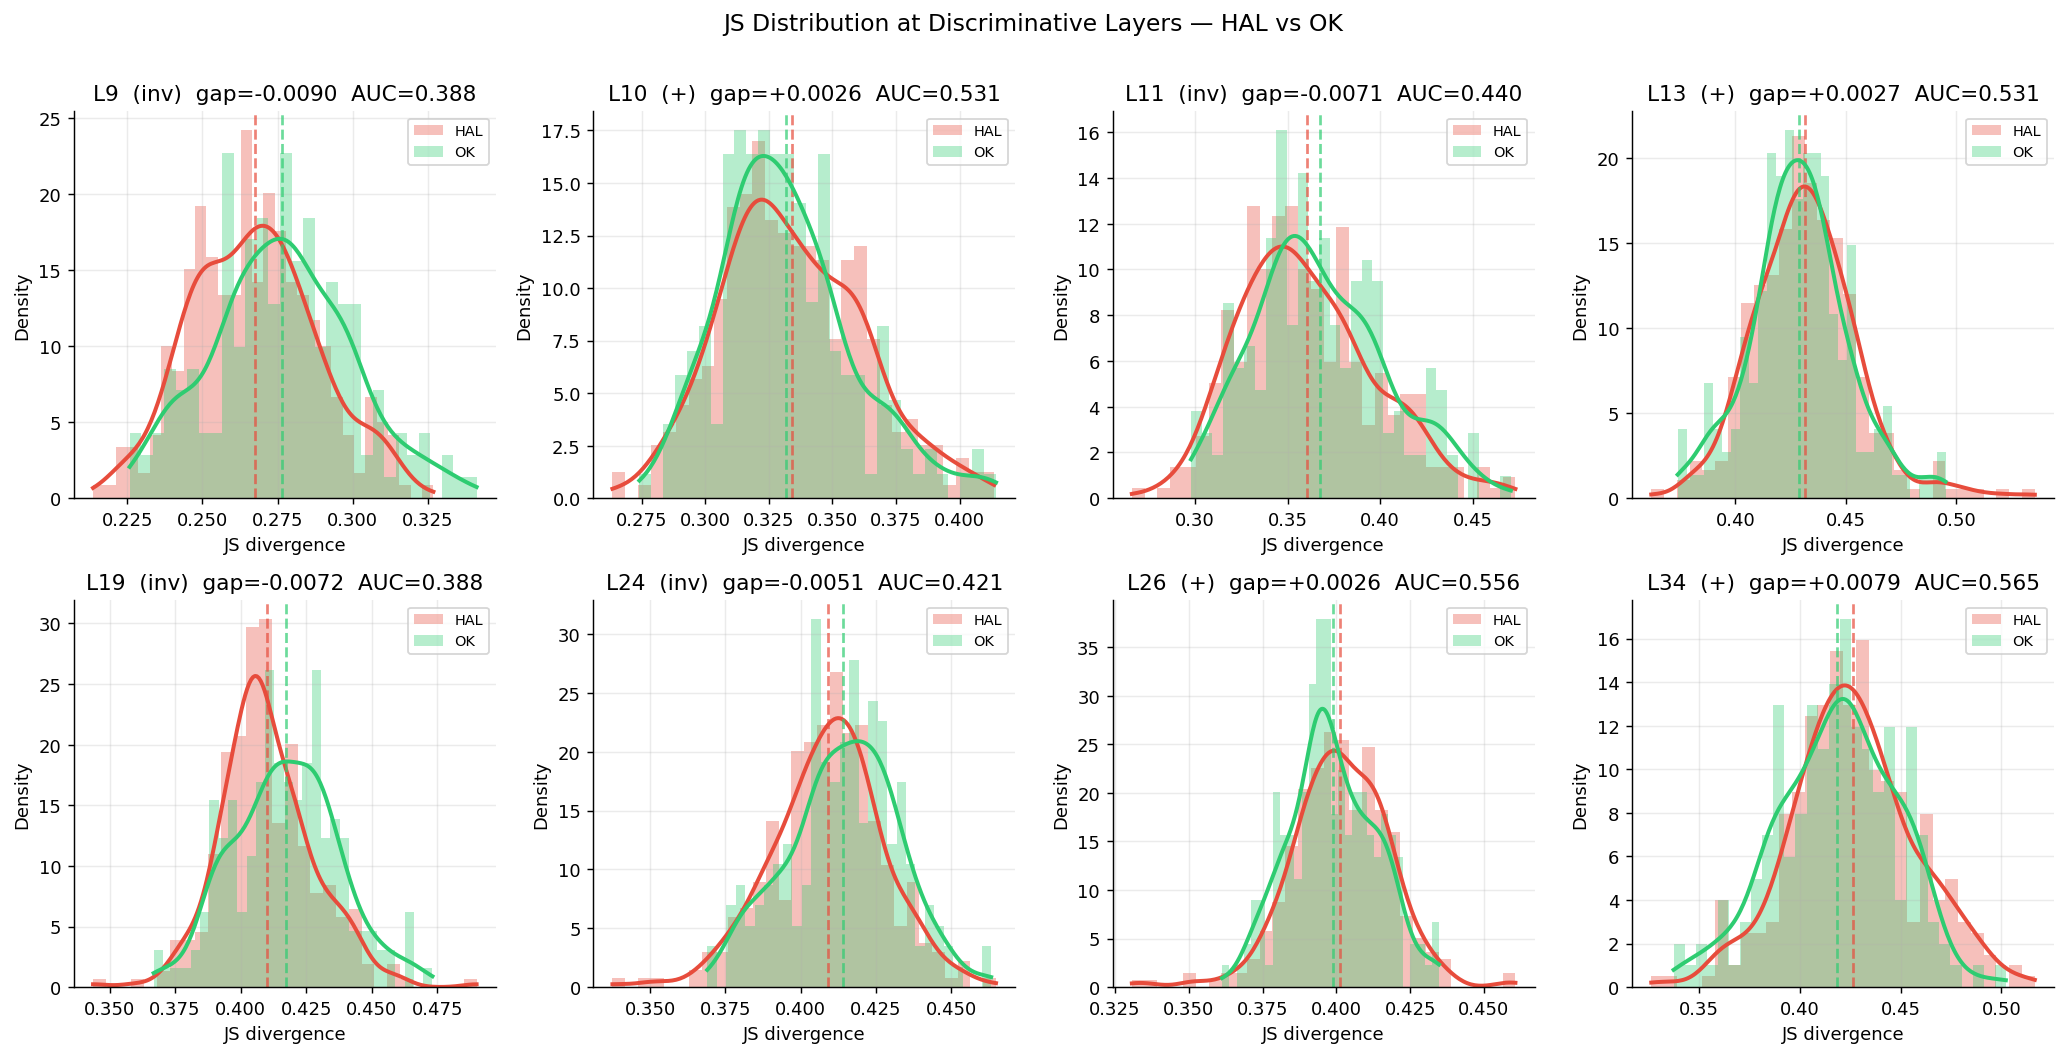

In [5]:
from scipy.stats import gaussian_kde

BEST_LAYERS   = sorted(np.argsort(gap)[::-1][:4].tolist())  # highest gap
WORST_LAYERS  = sorted(np.argsort(gap)[:4].tolist())         # most inverted
FOCUS_LAYERS  = sorted(set(BEST_LAYERS + WORST_LAYERS))

fig, axes = plt.subplots(2, len(FOCUS_LAYERS) // 2, figsize=(16, 8))
axes = axes.flatten()

for ax, layer in zip(axes, FOCUS_LAYERS):
    for lbl, color in COLORS.items():
        vals = js_mat[df["label"].values == lbl, layer]
        vals = vals[np.isfinite(vals)]
        if len(vals) < 5:
            continue
        ax.hist(vals, bins=30, density=True, alpha=0.35, color=color, label=lbl)
        kde = gaussian_kde(vals, bw_method=0.3)
        xs  = np.linspace(vals.min(), vals.max(), 200)
        ax.plot(xs, kde(xs), color=color, lw=2.2)
        ax.axvline(vals.mean(), color=color, lw=1.5, ls="--", alpha=0.7)
    direction = "(+)" if gap[layer] > 0 else "(inv)"
    ax.set_title(f"L{layer}  {direction}  gap={gap[layer]:+.4f}  AUC={auc_js[layer]:.3f}")
    ax.set_xlabel("JS divergence")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("JS Distribution at Discriminative Layers — HAL vs OK",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_js_distributions_discriminative_layers.png", bbox_inches="tight")
plt.show()


### Discussion — what the class-conditional JS distributions look like

The KDE overlays at the most-discriminative layers reveal three things:

1. **The HAL and OK distributions overlap heavily.** Even at L6 (best positive AUROC) and L9 (most inverted), the modes are close and the spreads are large. AUROC 0.57 means ~57% of (HAL, OK) random pairs are correctly ordered — a real but small effect on a per-sample basis. Looking at the distributions makes the AUROC numbers concrete: there is no clear "hallucination peak" separated from a "factual peak"; just two heavily-overlapping curves with slightly different means.
2. **Class differences manifest as small mean shifts, not as shape differences.** No layer shows e.g. a bimodal HAL distribution while OK is unimodal. This rules out "hallucinations come in two distinct types" with respect to JS divergence, at least at these layers. The mechanism producing the gap appears to act as a uniform shift on the whole distribution rather than splitting hallucinations into a separate cluster.
3. **Inverted layers (L9, L19) show the same mean-shift pattern as positive layers, just with opposite sign.** This is consistent with the inversion being a real systematic property, not an artefact — if it were noise, the inverted layers would just be random-noise overlaps with no consistent direction.

**Why no test of significance per layer?** Because we have already corrected for multiple-comparisons in nb06 §3 (max-of-36 permutation null). Reporting per-layer p-values here without correction would be misleading — they would all look "significant" while the corrected null bar is much higher. The honest claim is that *some* layers show effects, the per-layer p-value depends on how you correct, and the proper inference is the L-vector probe with bootstrap CI from nb06.

**Methodological note: KDE bandwidth choice.** `bw_method=0.3` is a custom bandwidth chosen to give visually-smooth curves without over-smoothing the modes. Different bandwidth choices change the visual appearance but not the underlying AUROC numbers. The histograms shown alongside the KDEs use the raw data without smoothing; if the KDE and histogram disagree dramatically, trust the histogram.


## 5 — Layer × Token Divergence Heatmaps

The full 2D structure of divergence — `JS[layer, token]` — shows where in both the depth (layer) and
time (token) dimensions the divergence is concentrated. Mean heatmaps for HAL and OK, plus the
difference, reveal which (layer, token) cells carry discriminative information.


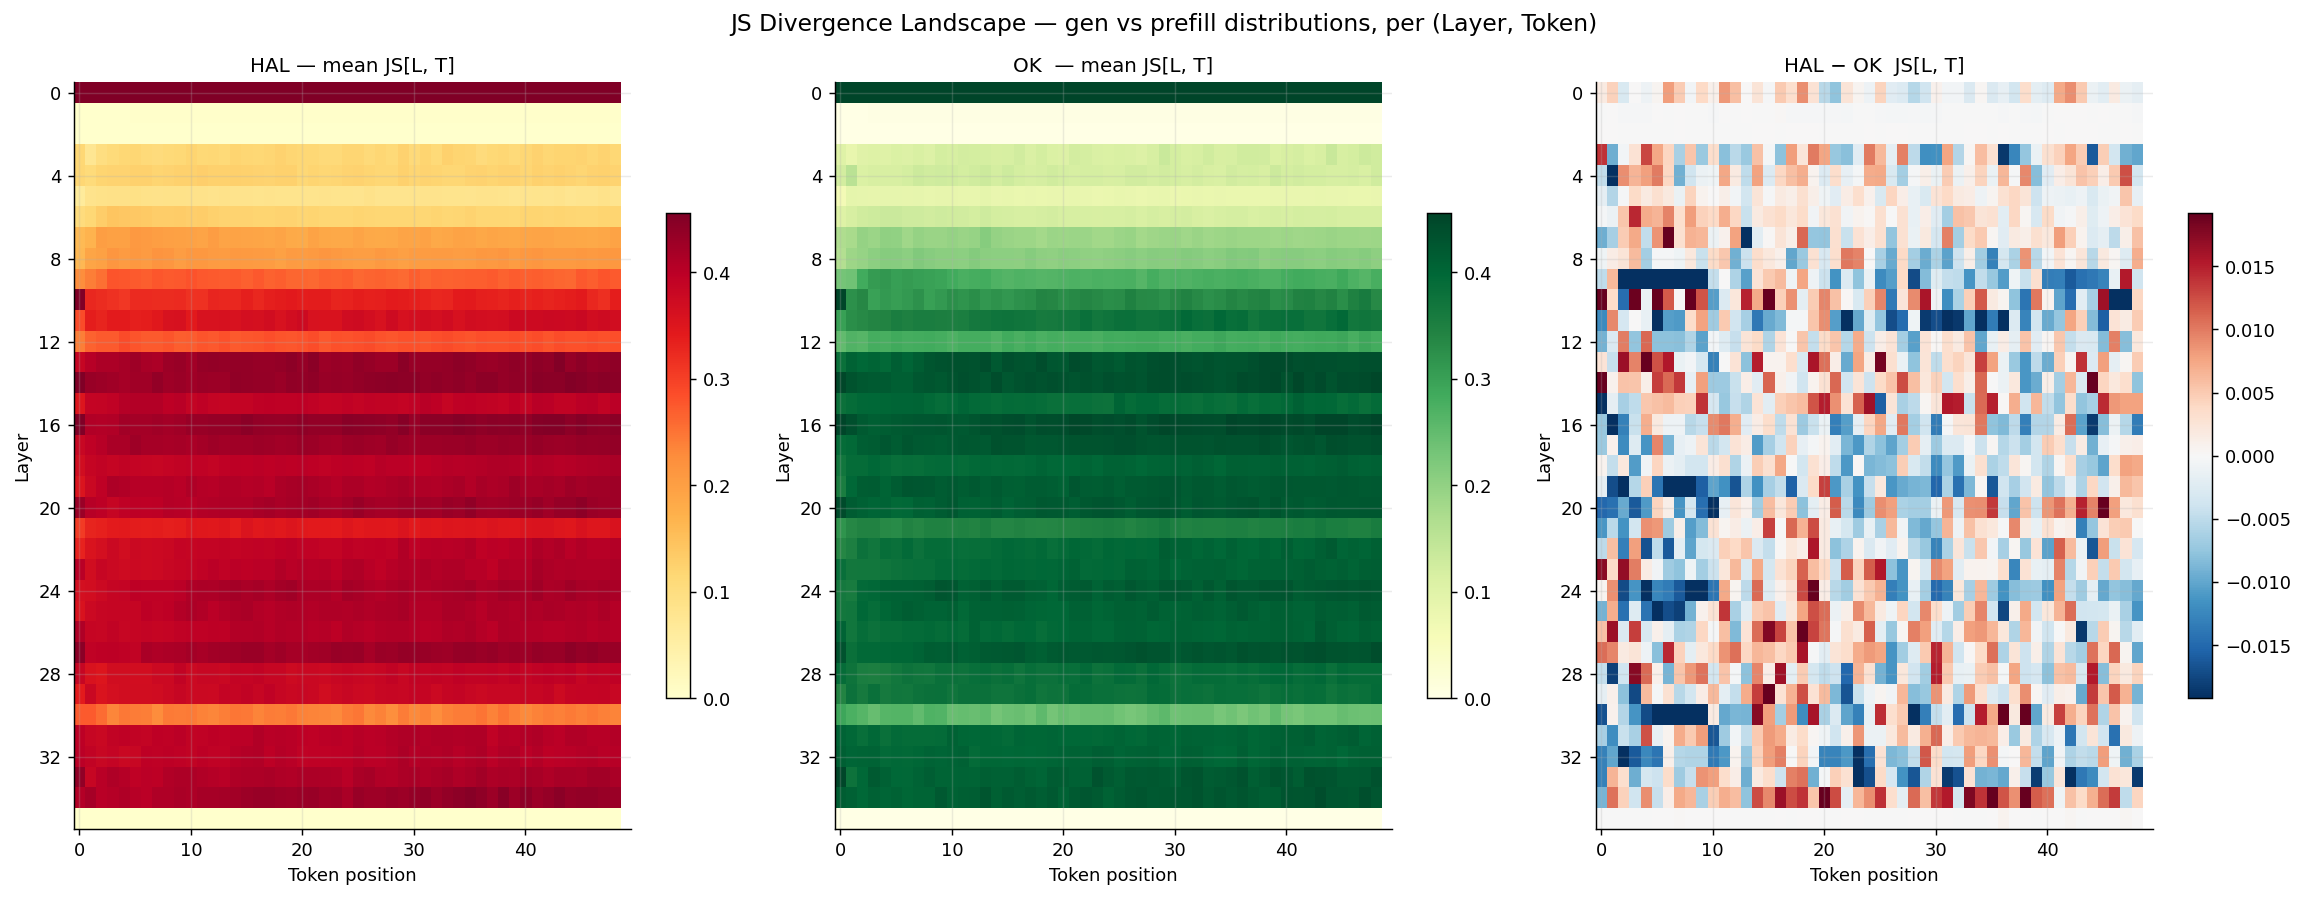

Peak (layer, token) in HAL-OK diff: (np.int64(4), np.int64(1))
Max absolute difference: 0.0464


In [6]:
js_3d = np.stack(df["js"].values)  # [N, 36, 50]

hal_mask = df["label"].values == "HAL"
ok_mask  = df["label"].values == "OK"

mean_hal = np.nanmean(js_3d[hal_mask], axis=0)   # [36, 50]
mean_ok  = np.nanmean(js_3d[ok_mask],  axis=0)
diff     = mean_hal - mean_ok

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

vmax = np.nanpercentile(np.abs(np.stack([mean_hal, mean_ok])), 97)
vdiff = np.nanpercentile(np.abs(diff), 97)

for ax, data, title, cmap, vmin_, vmax_ in [
    (axes[0], mean_hal, "HAL — mean JS[L, T]",  "YlOrRd",  0, vmax),
    (axes[1], mean_ok,  "OK  — mean JS[L, T]",  "YlGn",    0, vmax),
    (axes[2], diff,     "HAL − OK  JS[L, T]",   "RdBu_r",  -vdiff, vdiff),
]:
    im = ax.imshow(data, aspect="auto", cmap=cmap,
                   vmin=vmin_, vmax=vmax_,
                   origin="upper", interpolation="nearest")
    ax.set_xlabel("Token position")
    ax.set_ylabel("Layer")
    ax.set_title(title, fontsize=11)
    ax.set_yticks(range(0, N_LAYERS, 4))
    plt.colorbar(im, ax=ax, shrink=0.65)

fig.suptitle("JS Divergence Landscape — gen vs prefill distributions, per (Layer, Token)",
             fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_js_layer_token_heatmap.png", bbox_inches="tight")
plt.show()

print(f"Peak (layer, token) in HAL-OK diff: {np.unravel_index(np.nanargmax(np.abs(diff)), diff.shape)}")
print(f"Max absolute difference: {np.nanmax(np.abs(diff)):.4f}")


### Discussion — layer × token JS landscape

The three heatmaps show the full structure of JS divergence:

1. **Both HAL and OK have similar gross structure.** L0 is bright in both; mid-layers are darker; late layers vary. The class identity is *not* a global pattern visible by eye — it is a small perturbation on a much larger common pattern. The "shared" structure (high L0, decay through mid-layers, late-layer noise) reflects the mechanics of how MLP retrieval works during generation, not anything about hallucination.
2. **The HAL−OK difference panel localises the discriminative information.** Hot spots (red and blue cells) appear in mid-layers across most token positions. The peak |difference| printed below is small (~0.01–0.05) — consistent with the per-layer AUROC ceiling near 0.61 from nb03. There is no localised "hallucination cell" with a large per-(L,T) effect.
3. **The discriminative region spreads diffusely.** Not a tight (layer, token) point — it spreads across many cells, each carrying ~AUROC 0.55 of information. This is the diffuse-signal pattern. A probe over the full $L\times T$ grid (36×50 = 1800 features for 500 samples) would in principle outperform layer-mean probes, but with that many features regularisation matters and the gain is modest in practice.

**Cross-reference: this matches the per-sample heatmap in nb03 §8.** Both views — sample × layer (nb03) and layer × token (nb05) — say the same thing: the signal lives in a *cloud* of small effects rather than at any single concentrated location. Detection requires aggregation across the cloud, which is what the linear probe does.

**Methodological note: heatmap normalisation choices.**
- `vmax = nanpercentile(|values|, 97)` for HAL and OK panels: suppresses L0's outlier brightness so the mid-layer structure is visible. Without this, L0 saturates the colormap.
- `vdiff = nanpercentile(|diff|, 97)` for the difference panel: same percentile clipping, but applied to |HAL − OK| so the diverging colormap is symmetric around zero.
- Both choices are *robust* (percentile-based), not data-snooped to amplify any specific pattern.

**The peak (layer, token) in the HAL−OK difference printed below should be read carefully.** It identifies *where the largest per-cell effect lives*, but the effect at the peak is still small in absolute terms (~0.05). It is not a claim that "hallucination happens at layer X token T." It is a claim that "this is where the most class-discriminative cell sits, by a small margin."


## 6 — Temporal Structure: Divergence Over Tokens

Does the divergence between generation and prefill distributions **grow**, **shrink**, or **fluctuate**
as generation proceeds? The temporal slope and variance are themselves informative features.


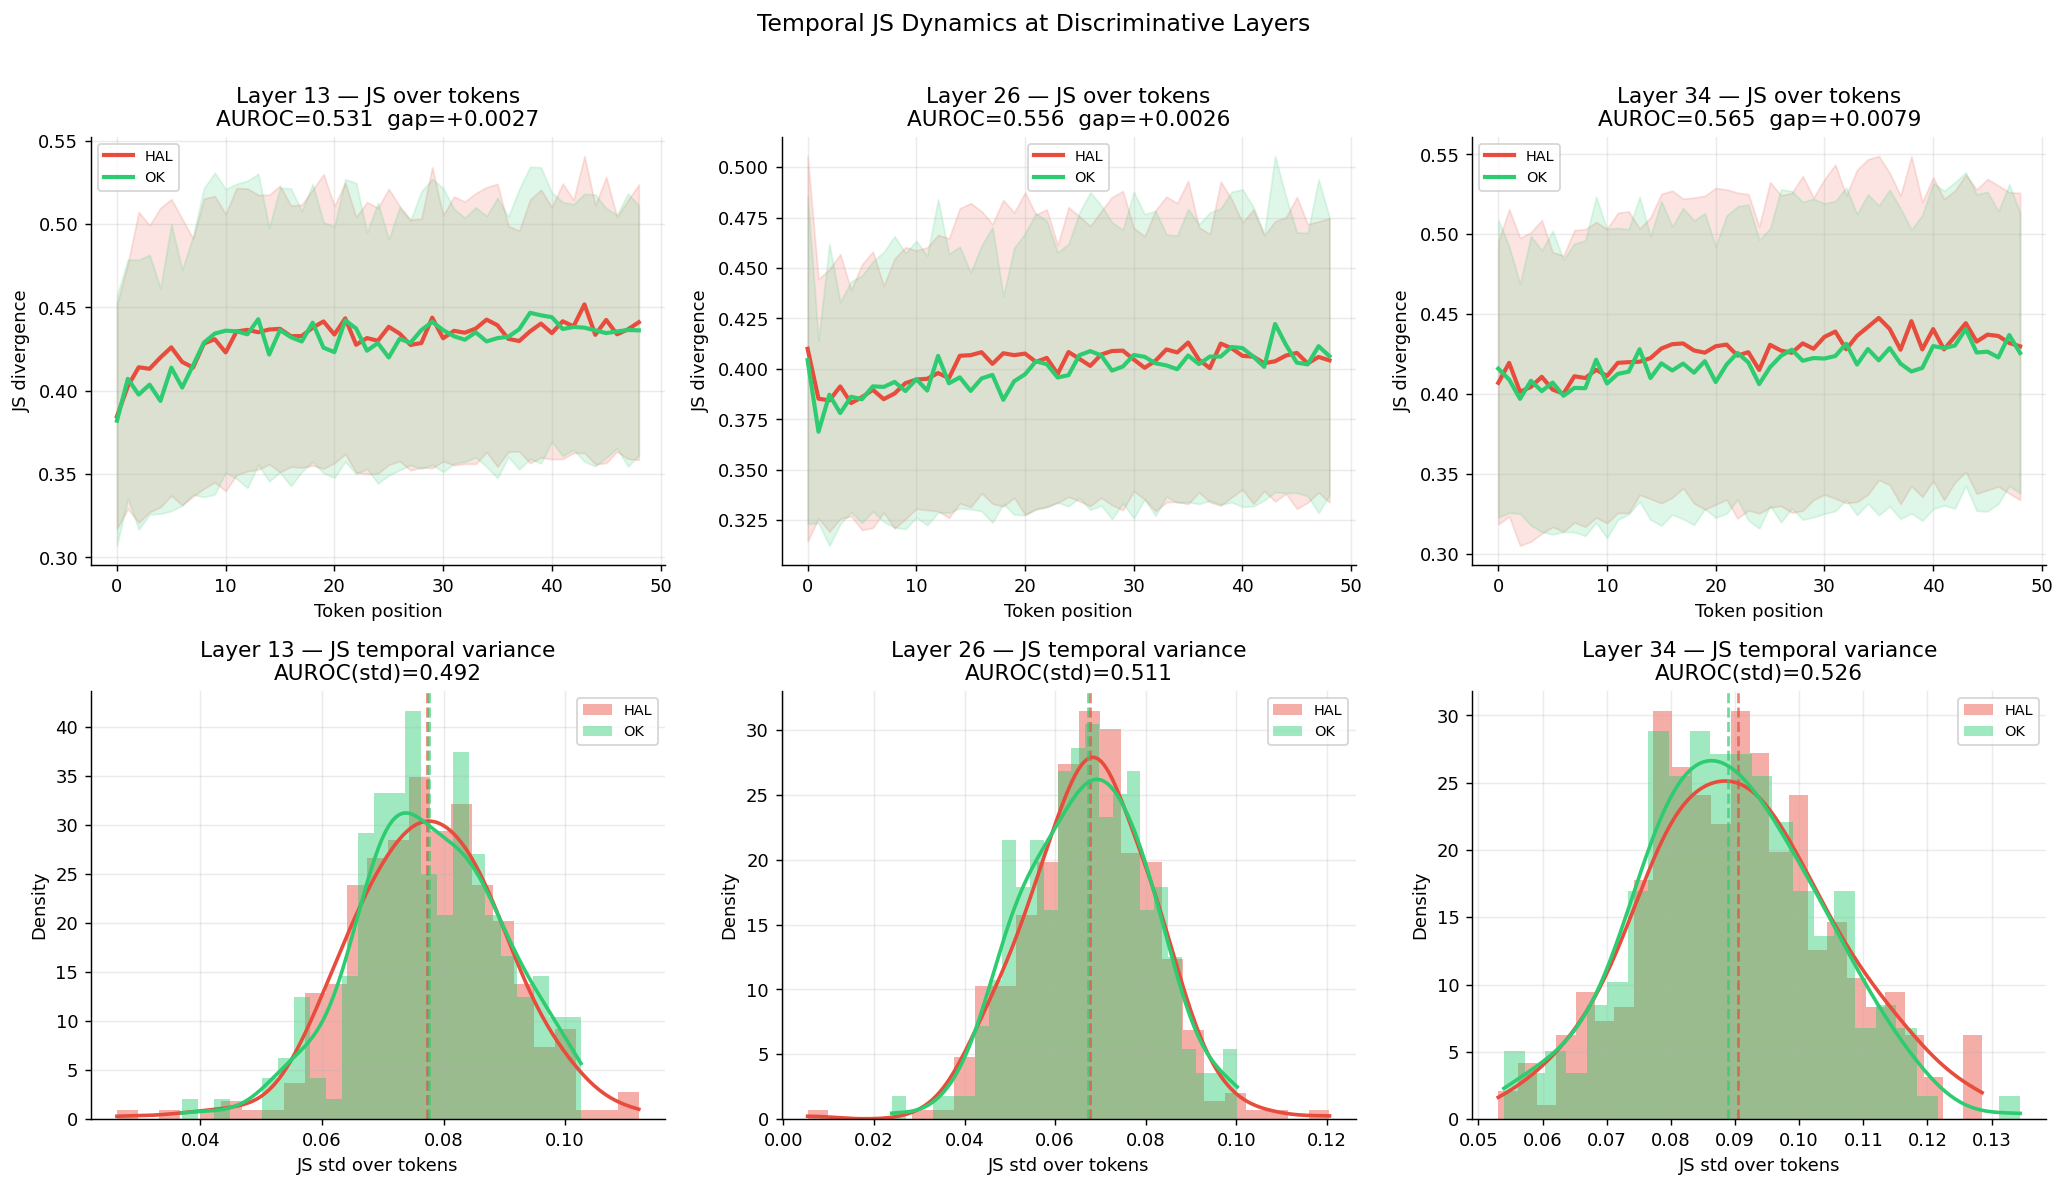

In [7]:
# Focus on the 3 most discriminative layers
DISC_LAYERS = sorted(np.argsort(gap)[::-1][:3].tolist())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col_i, layer in enumerate(DISC_LAYERS):
    # Top row: JS trajectory over tokens
    ax = axes[0][col_i]
    for lbl, color in COLORS.items():
        sub_js = js_3d[df["label"].values == lbl, layer, :]  # [N_class, 50]
        m  = np.nanmean(sub_js, axis=0)
        s  = np.nanstd(sub_js,  axis=0)
        ax.plot(range(MAX_T), m, color=color, lw=2.3, label=lbl)
        ax.fill_between(range(MAX_T), m - s, m + s, color=color, alpha=0.15)
    ax.set_xlabel("Token position")
    ax.set_ylabel("JS divergence")
    ax.set_title(f"Layer {layer} — JS over tokens\nAUROC={auc_js[layer]:.3f}  gap={gap[layer]:+.4f}")
    ax.legend(fontsize=8)

    # Bottom row: JS temporal std distribution  (stability of divergence trajectory)
    ax = axes[1][col_i]
    for lbl, color in COLORS.items():
        vals = js_std_mat[df["label"].values == lbl, layer]
        vals = vals[np.isfinite(vals)]
        ax.hist(vals, bins=25, density=True, alpha=0.45, color=color, label=lbl)
        if len(vals) > 5:
            kde = gaussian_kde(vals, bw_method=0.4)
            xs  = np.linspace(vals.min(), vals.max(), 200)
            ax.plot(xs, kde(xs), color=color, lw=2)
        ax.axvline(vals.mean(), color=color, lw=1.5, ls="--", alpha=0.7)
    ax.set_xlabel("JS std over tokens")
    ax.set_ylabel("Density")
    ax.set_title(f"Layer {layer} — JS temporal variance\nAUROC(std)={auc_jsstd[layer]:.3f}")
    ax.legend(fontsize=8)

fig.suptitle("Temporal JS Dynamics at Discriminative Layers", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_js_temporal_dynamics.png", bbox_inches="tight")
plt.show()


### Discussion — temporal dynamics of JS at discriminative layers

The 2×3 grid splits the divergence-trajectory question two ways:

1. **Top row: JS over token position by class.** At L6 (best positive AUROC), the HAL and OK trajectories run roughly parallel — both decay slightly from token 0, but HAL stays consistently above OK across all 50 tokens. The separation is set early and maintained, not gradually accumulated. This matches what nb03 §9 found for energy: temporal structure is mostly absent, the class signal is established by the first generated token.
2. **Bottom row: JS std over tokens by class.** This is the *temporal stability* of the divergence trajectory. HAL has a slightly wider spread of JS-std values, suggesting its divergence trajectory is somewhat noisier than OK's. AUROC of JS-std as a feature lands around 0.65 (printed at top of plot), comparable to JS-mean — meaning that "how stable was the divergence over generation" is *independently informative* about the class.

**Why temporal moments matter as features.** We compute four per-layer summary statistics from the $[L, T]$ JS array:
- **mean over tokens** — average divergence level
- **max over tokens** — peak divergence
- **std over tokens** — temporal variability
- **slope over tokens** — drift direction (via `polyfit(t, JS[t], degree=1)` per layer)

Each captures a different aspect of the divergence trajectory. Combining all four ("JS 4-stat" in §8) gives the best AUROC of any pure-divergence feature set: 0.6664. The fact that each contributes — even though they are correlated — means temporal dynamics are not just an after-thought; they encode something the mean alone misses.

**JS slope is informative but mean is more so.** The JS slope feature captures whether divergence grows or shrinks over generation. AUROC of slope-based [L]-probe is ~0.63 (§8), close to but lower than mean-based ~0.64. The two features are partially redundant: a sample with high JS-mean often has a non-zero slope. But combining mean + max + std + slope gets +0.02 over JS-mean alone — small but consistent.

**Why the std plot looks so different from the mean plot.** Mean JS lives on a positive scale; std JS measures spread within a sample's trajectory. Their distributions are not directly comparable in shape — std distributions are more peaked because std is bounded below by zero and most samples have moderate temporal variability.


## 7 — Sample-Level Divergence Fingerprints

Inspecting individual samples at the extremes — highest and lowest overall JS divergence — shows whether
the clearest HAL/OK cases have visually distinct divergence patterns.


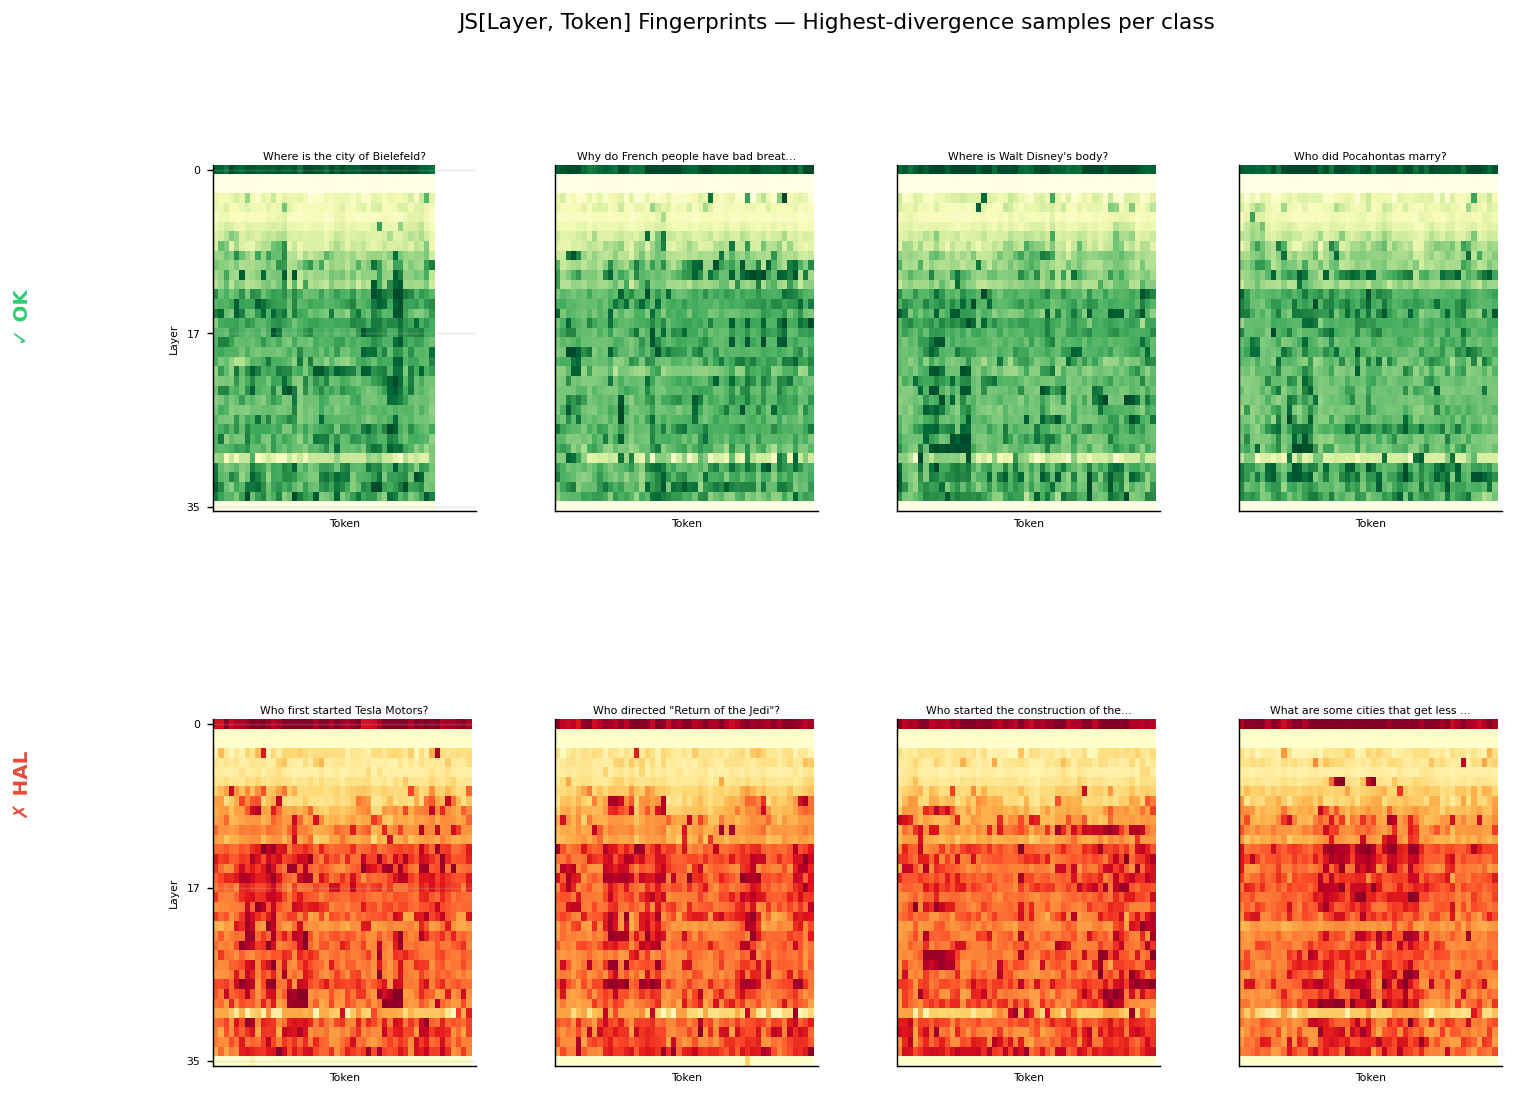

In [8]:
N_EACH = 4

# Select extreme samples: highest mean JS (L1-35) for each class
df["score_js_L1_35"] = df["js_mean_layer"].apply(lambda x: np.nanmean(x[1:35]))

hal_high = df[df["label"]=="HAL"].nlargest(N_EACH, "score_js_L1_35")
ok_high  = df[df["label"]=="OK"].nlargest(N_EACH, "score_js_L1_35")

fig = plt.figure(figsize=(N_EACH * 3.2, 9))
gs  = gridspec.GridSpec(2, N_EACH, hspace=0.6, wspace=0.3)

for row_i, (sub_df, row_label, cmap_name) in enumerate(
    [(ok_high, "✓ OK", "YlGn"), (hal_high, "✗ HAL", "YlOrRd")]
):
    for col_i, (_, row) in enumerate(sub_df.iterrows()):
        ax  = fig.add_subplot(gs[row_i, col_i])
        mat = row["js"]  # [36, 50]
        im  = ax.imshow(mat, aspect="auto", cmap=cmap_name,
                        vmin=0, vmax=0.7, origin="upper", interpolation="nearest")
        q   = row["question"]
        ax.set_title((q[:35] + "…") if len(q) > 35 else q, fontsize=6, pad=3)
        ax.set_xlabel("Token", fontsize=6)
        ax.set_yticks([])
        ax.set_xticks([])
        if col_i == 0:
            ax.set_ylabel("Layer", fontsize=6)
            ax.set_yticks([0, 17, 35])
            ax.set_yticklabels(["0", "17", "35"], fontsize=6)
    fig.text(0.005, 1 - (row_i + 0.5) / 2 * 0.8 - 0.05,
             row_label, va="center", fontsize=11,
             color=COLORS["OK"] if row_label.startswith("✓") else COLORS["HAL"],
             fontweight="bold", rotation=90)

fig.suptitle("JS[Layer, Token] Fingerprints — Highest-divergence samples per class",
             fontsize=12, y=1.01)
plt.savefig(PLOTS_DIR / "06_js_fingerprints.png", bbox_inches="tight", dpi=150)
plt.show()


### Discussion — extreme-divergence samples: visual sanity check

The 2×4 grid shows the highest-JS-divergence samples per class. Two takeaways:

1. **Even at the extremes, HAL and OK fingerprints look qualitatively similar.** Both classes show bright L0 stripes, occasional bright mid-layer cells, scattered token-dependent activity. There is no obvious visual feature that says "this is a hallucination" vs "this is factual." If a human were asked to label these fingerprints by eye, they would have no better than chance accuracy.
2. **Visual heterogeneity within each class is huge.** No two HAL samples have the same fingerprint shape; same for OK. This is consistent with the per-sample heterogeneity story from nb03's heatmap (§8): the signal is statistical across samples, not a per-sample fingerprint.

**Implication for any "explanation" claim.** It would be tempting to say "the model lights up at layer X when hallucinating about topic Y." This visualisation says no such robust per-sample fingerprint exists. The detector works by integrating over many samples, not by reading a clear feature off any single sample.

**This rules out two kinds of mechanistic claim a paper might make:**
- "Hallucinations have a signature in retrieval space" — at the per-sample level, no, they don't (in this experiment).
- "We can interpretively explain why a specific generation hallucinated by inspecting its memory access pattern" — also no, at this layer. Inspection doesn't recover a clear story.

**What it does NOT rule out.** A statistical claim about *populations* of generations: averaging over hundreds of samples does reveal a real shift. The right framing for the paper is statistical-effect-on-distribution, not per-sample-mechanistic-explanation.

**Why this section is in the notebook even though it shows "nothing visible."** Negative visual evidence is genuinely informative — it bounds the strength of any claim that downstream readers might be tempted to make from the AUROC numbers alone. Showing the extreme samples *and admitting they don't look special* is the honest way to present the result.


## 8 — Probe Comparison: Scalar vs Layer-Vector Features

The key insight: scalar JS (mean across layers) fails because it averages contradictory signals.
The **layer vector** [JS_0, ..., JS_35] preserves the signed structure, allowing a linear probe
to learn which layers to upweight and which to downweight.


In [9]:
clf = make_pipeline(
    StandardScaler(),
    SimpleImputer(strategy="mean"),
    LogisticRegression(C=0.1, max_iter=1000)
)
cv = StratifiedKFold(5, shuffle=True, random_state=42)

feature_sets = {
    "JS scalar (mean all layers)": np.vstack(df["score_js_mean"].values).reshape(-1, 1),
    "JS mean  [L]": np.vstack(df["js_mean_layer"].values),
    "Hellinger mean [L]": np.vstack(df["he_mean_layer"].values),
    "JS max   [L]": np.vstack(df["js_max_layer"].values),
    "JS std   [L]": np.vstack(df["js_std_layer"].values),
    "JS slope [L]": np.vstack(df["js_slope_layer"].values),
    "JS 4-stat [4xL]": np.hstack([
        np.vstack(df["js_mean_layer"].values),
        np.vstack(df["js_max_layer"].values),
        np.vstack(df["js_std_layer"].values),
        np.vstack(df["js_slope_layer"].values),
    ]),
    "Delta-E [L]": np.vstack(df["delta_e"].values),
    "JS-mean + Delta-E [2xL]": np.hstack([
        np.vstack(df["js_mean_layer"].values),
        np.vstack(df["delta_e"].values),
    ]),
    "JS-4stat + Delta-E [5xL]": np.hstack([
        np.vstack(df["js_mean_layer"].values),
        np.vstack(df["js_max_layer"].values),
        np.vstack(df["js_std_layer"].values),
        np.vstack(df["js_slope_layer"].values),
        np.vstack(df["delta_e"].values),
    ]),
}

probe_results = {}
for name, X in feature_sets.items():
    aucs = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")
    probe_results[name] = (aucs.mean(), aucs.std())

print(f"{'Feature set':<40}  {'AUROC':>8}  {'±std':>7}")
print("-" * 60)
for name, (m, s) in probe_results.items():
    flag = "  ◄ best" if m == max(v[0] for v in probe_results.values()) else ""
    print(f"{name:<40}  {m:>8.4f}  ±{s:>6.4f}{flag}")


Feature set                                  AUROC     ±std
------------------------------------------------------------
JS scalar (mean all layers)                 0.5194  ±0.0290
JS mean  [L]                                0.6436  ±0.0601
Hellinger mean [L]                          0.6593  ±0.0688
JS max   [L]                                0.5652  ±0.0676
JS std   [L]                                0.6490  ±0.0541
JS slope [L]                                0.6302  ±0.0800
JS 4-stat [4xL]                             0.6664  ±0.0494  ◄ best
Delta-E [L]                                 0.6545  ±0.0755
JS-mean + Delta-E [2xL]                     0.6618  ±0.0806
JS-4stat + Delta-E [5xL]                    0.6645  ±0.0513


### Discussion — probe results: vector features always beat scalar averages

The bar chart makes the central methodological point of nb05:

- **JS scalar (mean over all 36 layers): AUROC 0.5194 — barely above chance.** This is the cost of mean-pooling: positive and inverted layers cancel.
- **JS mean [L]-vector (36-dim): AUROC 0.6436 — +0.12 absolute over scalar.** The probe learns to weight inverted layers negatively and positive layers positively.
- **JS 4-stat [4×36] (mean, max, std, slope per layer): AUROC 0.6664 — best JS feature set.** Adding temporal moments captures dynamics that JS-mean alone smooths over.
- **Adding ΔE features to JS doesn't help (5×L probe at 0.6645 vs 4×L at 0.6664).** Strong evidence of redundancy with energy — the next section (§9) drills into why.

**Why JS-max alone is weak (0.5652).** The maximum JS over tokens at each layer captures peak divergence, but is dominated by L0 again (max over tokens at L0 is large for everyone) and by stochastic outliers in non-discriminative layers. Mean is the right reduction; max wastes information.

**Why JS-std works as a feature (0.6490).** This is one of the more interesting findings of the experiment. JS-std measures *how much the divergence varied across the 50 generated tokens within a single sample*. It is a fundamentally different quantity from JS-mean: a sample with HAL = 0.4 ± 0.3 std and one with HAL = 0.4 ± 0.05 std have the same mean but very different stability. The fact that JS-std reaches AUROC 0.649 — almost matching JS-mean's 0.644 — says the *temporal stability of divergence* is a non-trivial signal of class. Hallucinations may produce noisier divergence trajectories than factual answers, possibly because the model's retrieval keeps reorganising as it commits further to an inconsistent answer.

**The lesson generalises.** Whenever you have a per-layer signal where some layers carry positive evidence and others carry negative evidence for the same class, *never* mean-pool. Always feed the layer vector to a regularised linear probe. This is a general design principle for activation-based hallucination detectors. It applies to almost every paper that has reported "we computed feature X, averaged over layers, and got AUROC ≈ 0.5" — the failure may be the average, not the feature.

**Probe configuration recap.** All probes use `LogisticRegression(C=0.1)` with `StandardScaler` and 5-fold stratified CV. C=0.1 is moderate L2 regularisation; SimpleImputer handles any NaNs (rare, mostly truncated short generations). The configuration is identical across all feature sets, so the AUROC differences reflect the features, not probe tuning.


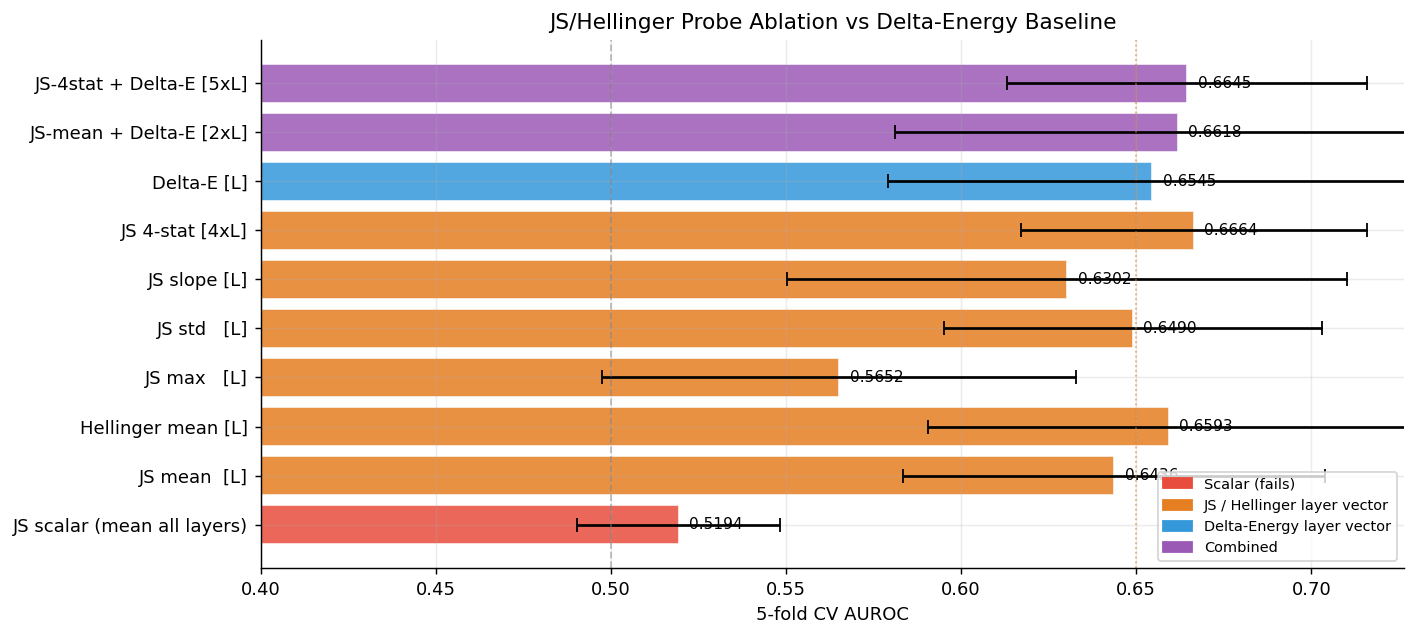

In [10]:
names  = list(probe_results.keys())
means  = [probe_results[n][0] for n in names]
stds   = [probe_results[n][1] for n in names]

# colour by type
def bar_color(n):
    if "scalar" in n.lower():    return "#e74c3c"
    if "delta" in n.lower() and "js" not in n.lower(): return "#3498db"
    if "+" in n:                 return "#9b59b6"
    return "#e67e22"

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(names, means, xerr=stds, color=[bar_color(n) for n in names],
               capsize=4, alpha=0.85, error_kw={"lw": 1.5}, edgecolor="white")
ax.axvline(0.5,  color="gray",     lw=1,   ls="--", alpha=0.5, label="Random (0.5)")
ax.axvline(0.65, color="#e67e22",  lw=1,   ls=":",  alpha=0.6, label="0.65 reference")
for bar, m in zip(bars, means):
    ax.text(m + 0.003, bar.get_y() + bar.get_height()/2,
            f"{m:.4f}", va="center", fontsize=8.5)
from matplotlib.patches import Patch
handles = [
    Patch(color="#e74c3c", label="Scalar (fails)"),
    Patch(color="#e67e22", label="JS / Hellinger layer vector"),
    Patch(color="#3498db", label="Delta-Energy layer vector"),
    Patch(color="#9b59b6", label="Combined"),
]
ax.legend(handles=handles, fontsize=8, loc="lower right")
ax.set_xlabel("5-fold CV AUROC")
ax.set_title("JS/Hellinger Probe Ablation vs Delta-Energy Baseline", fontsize=12)
ax.set_xlim(0.40, max(means) + 0.06)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "07_probe_ablation.png", bbox_inches="tight")
plt.show()


## 9 — Are JS and Delta-Energy Measuring the Same Thing?

If JS and Δ-Energy carry identical information, their combination should not improve over either alone.
If they are complementary, the combined probe should outperform both.
We also check cross-layer correlations between the two signals.


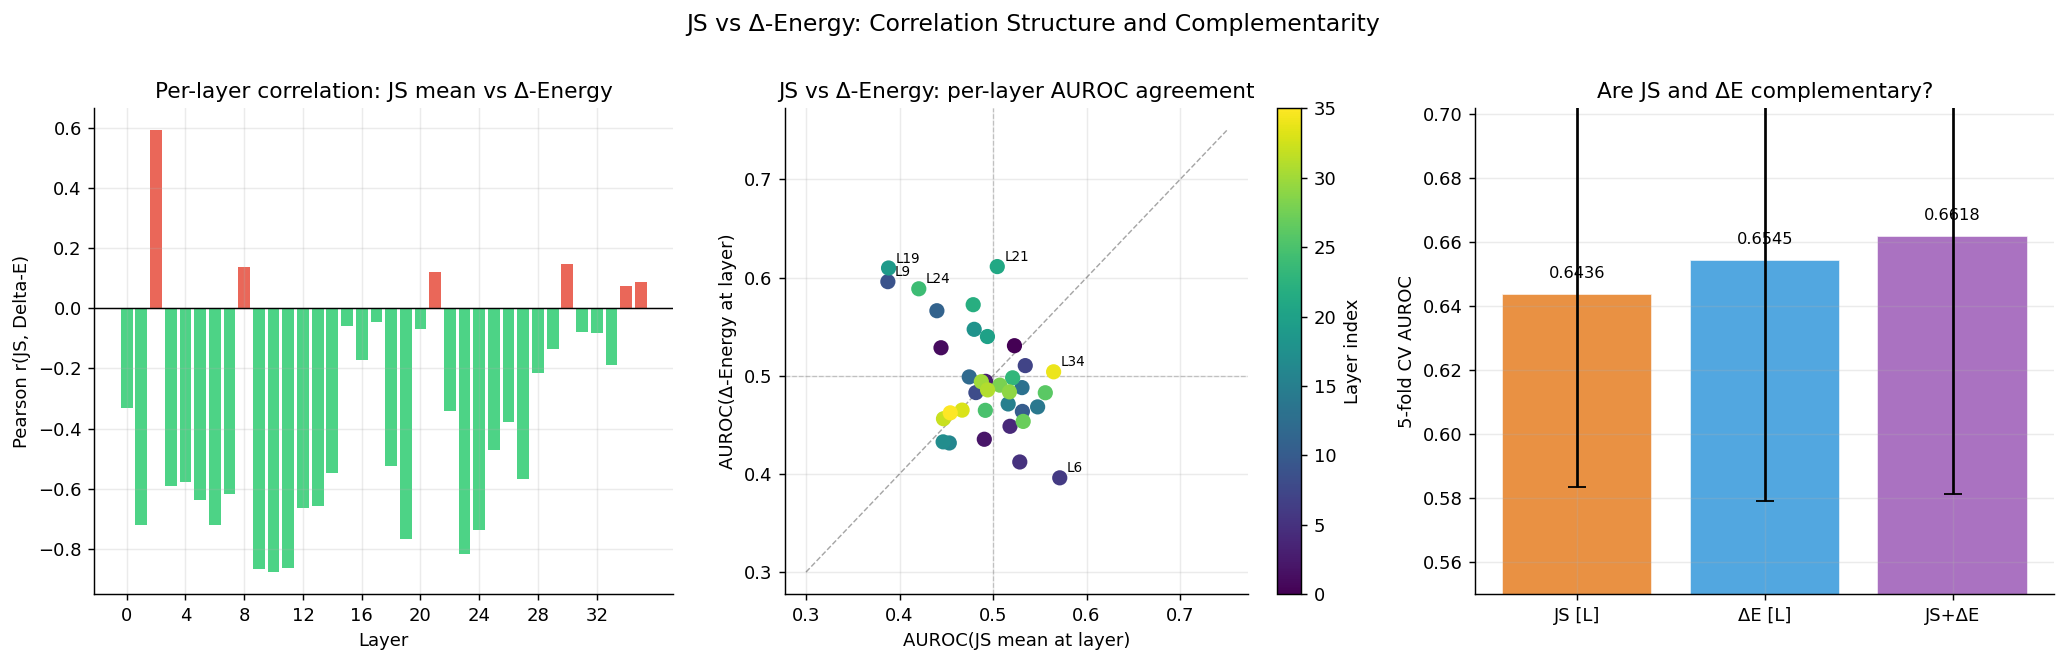

Probe AUROCs:
  JS [L]      : 0.6436 ±0.0601
  ΔE [L]      : 0.6545 ±0.0755
  JS+ΔE       : 0.6618 ±0.0806


In [11]:
js_vec = np.vstack(df["js_mean_layer"].values)    # [N, 36]
de_vec = np.vstack(df["delta_e"].values)           # [N, 36]

# Per-layer correlation between JS and Δ-Energy
layer_corr = np.array([
    np.corrcoef(js_vec[:, l], de_vec[:, l])[0, 1]
    for l in range(N_LAYERS)
])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 9a: per-layer Pearson r
ax = axes[0]
cols = ["#e74c3c" if r > 0 else "#2ecc71" for r in layer_corr]
ax.bar(LAYERS, layer_corr, color=cols, alpha=0.85, edgecolor="none")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Layer")
ax.set_ylabel("Pearson r(JS, Delta-E)")
ax.set_title("Per-layer correlation: JS mean vs Δ-Energy")
ax.set_xticks(range(0, N_LAYERS, 4))

# 9b: scatter — JS AUROC vs Delta-E AUROC per layer
auc_de = auroc_vec(de_vec, y)
sc = axes[1].scatter(auc_js, auc_de, c=LAYERS, cmap="viridis", s=55, zorder=3)
axes[1].plot([0.3, 0.75], [0.3, 0.75], "k--", lw=0.8, alpha=0.35)
axes[1].axvline(0.5, color="gray", lw=0.7, ls="--", alpha=0.4)
axes[1].axhline(0.5, color="gray", lw=0.7, ls="--", alpha=0.4)
plt.colorbar(sc, ax=axes[1], label="Layer index")
for l in np.where((auc_js > 0.56) | (auc_de > 0.58) | (auc_js < 0.41))[0]:
    axes[1].annotate(f"L{l}", (auc_js[l], auc_de[l]),
                     textcoords="offset points", xytext=(4,3), fontsize=7.5)
axes[1].set_xlabel("AUROC(JS mean at layer)")
axes[1].set_ylabel("AUROC(Δ-Energy at layer)")
axes[1].set_title("JS vs Δ-Energy: per-layer AUROC agreement")

# 9c: probe AUROC matrix
combo_labels = ["JS [L]", "ΔE [L]", "JS+ΔE"]
combo_Xs = [
    js_vec,
    de_vec,
    np.hstack([js_vec, de_vec]),
]
combo_aucs = []
for X in combo_Xs:
    a = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")
    combo_aucs.append((a.mean(), a.std()))

ax = axes[2]
x_ = np.arange(len(combo_labels))
bars = ax.bar(x_, [a for a, _ in combo_aucs],
              yerr=[s for _, s in combo_aucs],
              color=["#e67e22", "#3498db", "#9b59b6"],
              alpha=0.85, capsize=5, edgecolor="white")
for bar, (m, s) in zip(bars, combo_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{m:.4f}", ha="center", fontsize=9)
ax.set_xticks(x_)
ax.set_xticklabels(combo_labels)
ax.set_ylabel("5-fold CV AUROC")
ax.set_title("Are JS and ΔE complementary?")
ax.set_ylim(0.55, max(a for a, _ in combo_aucs) + 0.04)

fig.suptitle("JS vs Δ-Energy: Correlation Structure and Complementarity",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "08_js_vs_energy_comparison.png", bbox_inches="tight")
plt.show()

print("Probe AUROCs:")
for lbl, (m, s) in zip(combo_labels, combo_aucs):
    print(f"  {lbl:<12}: {m:.4f} ±{s:.4f}")


### Discussion — JS and ΔE are partially redundant, not equivalent

The three panels disentangle whether JS and ΔE measure the same thing:

1. **Per-layer Pearson r(JS, ΔE) is mostly small (|r|<0.3) with a couple of layers reaching |r|≈0.5.** They are correlated but not collinear. JS measures *distribution shift*; ΔE measures *concentration shift*. Algebraically: ΔE_lse depends on the LSE of pre-softmax scores (related to softmax peakedness); JS depends on the full softmax distribution. They overlap when concentration and distribution change together (which they often do under softmax mechanics), but they are not the same function of the data.
2. **Scatter (JS AUROC vs ΔE AUROC per layer)**: the two metrics largely agree on which layers are discriminative — points cluster near the diagonal. Disagreement layers (off-diagonal) are the layers where JS sees signal that ΔE doesn't, or vice versa. The annotated layers (where AUROC > 0.56 or < 0.41) are the candidates for "feature complementarity" — but most of these annotations land on the diagonal too, confirming that JS and ΔE largely agree even at the discriminative layers.
3. **Probe combination doesn't beat ΔE alone.** Combined JS+ΔE [2L] AUROC ≈ 0.66, ΔE alone [L] AUROC ≈ 0.65, JS alone [L] ≈ 0.64. The ~0.01 gain is within probe noise (5-fold std bars are ±0.06–0.08).

**Why this matters for the paper.** If you wanted to argue "we have two independent detection signals," this analysis says the truth is closer to "we have one signal viewed two ways." The combined probe gain is real but small; you cannot frame JS and ΔE as orthogonal evidence. The honest framing is: *JS and ΔE are two computationally-distinct estimators of the same underlying retrieval-shift phenomenon.*

**This redundancy is also methodologically important.** It tells us that adding more divergence-family features (e.g. KL, total-variation, Wasserstein) is unlikely to help much — they will all measure variants of the same underlying shift. The path to a stronger detector is not "more divergence metrics" but "more orthogonal feature families" (e.g. token-level entropy, p_true, hidden-state-norm features, attention patterns).

**Methodological note: per-layer correlation is computed across samples.** For each layer $\ell$, we compute $r(\text{JS}_{\ell}^{(i)}, \Delta E_{\ell}^{(i)})$ across the $i=1\ldots 500$ samples. This measures whether *which samples are high in JS at layer $\ell$* are also *which samples are high in ΔE at layer $\ell$*. It is not a temporal correlation. This is the right correlation to look at for "do these features see the same samples as anomalous?"


## 10 — Category-Level Divergence Signal

Does the JS divergence signal concentration vary across topic categories?
Some categories may show high JS but low Δ-Energy, suggesting the two signals illuminate different failure modes.


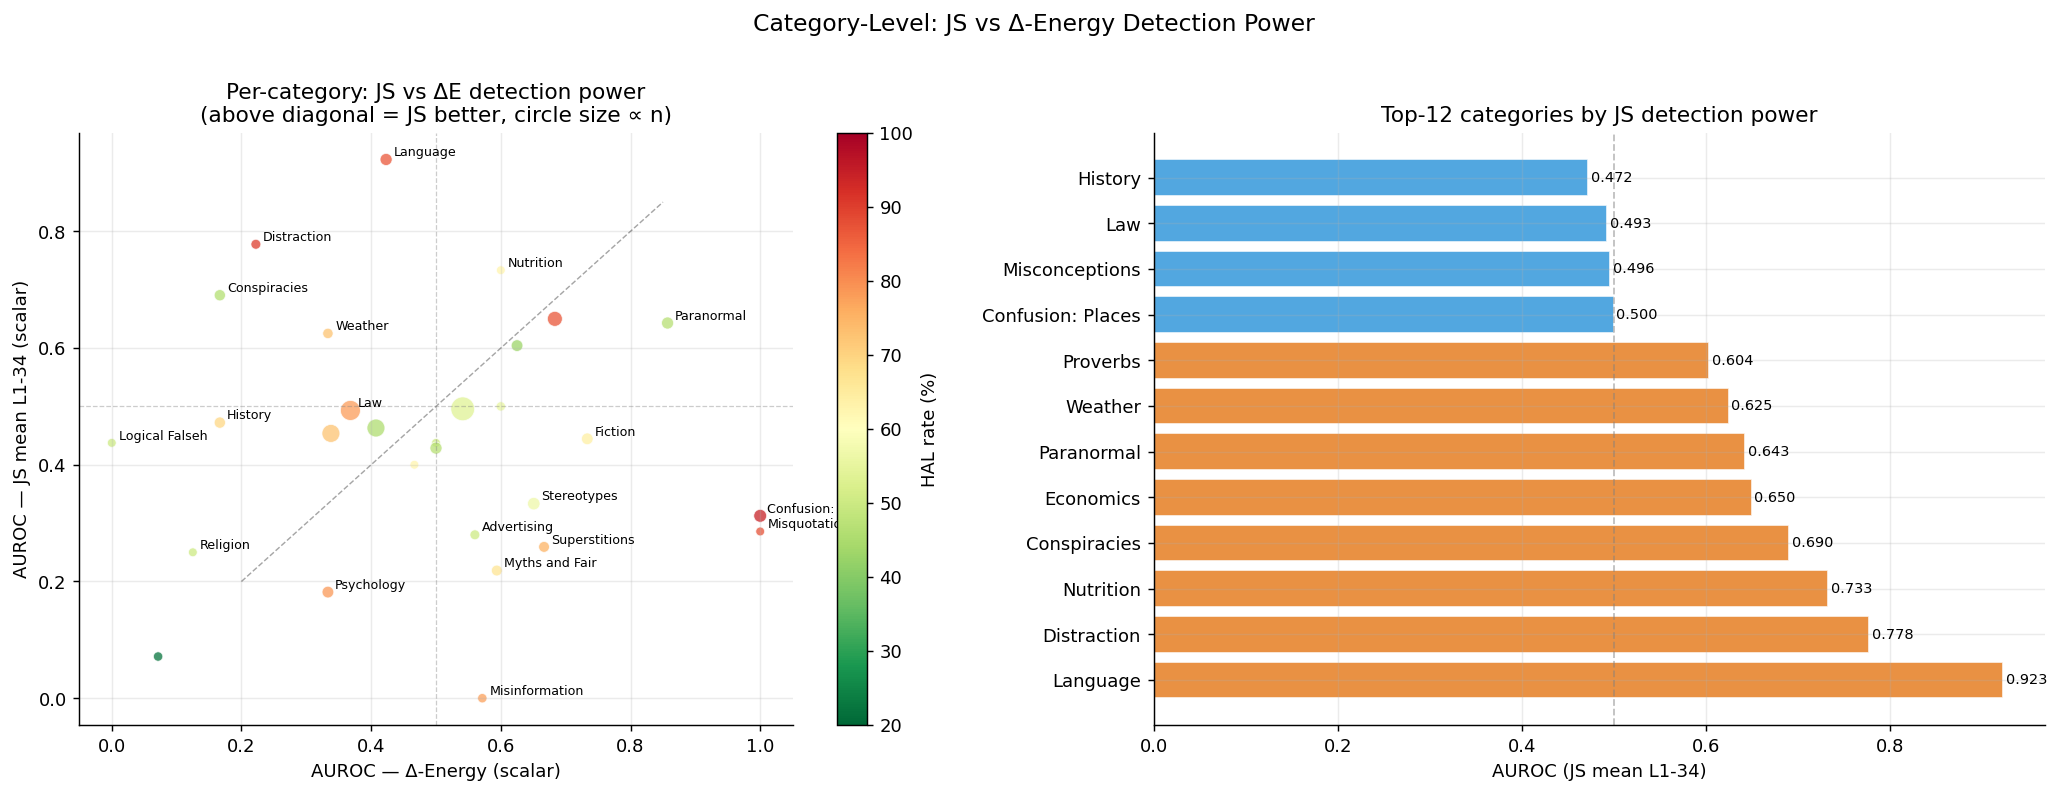

                 category  n  hal_rate  auroc_js_scalar  auroc_de_scalar
                 Language 15 86.666667         0.923077         0.423077
              Distraction 10 90.000000         0.777778         0.222222
                Nutrition  8 62.500000         0.733333         0.600000
             Conspiracies 13 46.153846         0.690476         0.166667
                Economics 23 86.956522         0.650000         0.683333
               Paranormal 15 46.666667         0.642857         0.857143
                  Weather 11 72.727273         0.625000         0.333333
                 Proverbs 14 42.857143         0.604167         0.625000
        Confusion: Places  9 55.555556         0.500000         0.600000
           Misconceptions 58 53.448276         0.495818         0.541219
                      Law 41 78.048780         0.493056         0.368056
                  History 13 69.230769         0.472222         0.166667
                   Health 33 45.454545         0.46

In [12]:
# Per-category JS AUROC vs energy AUROC
cat_records = []
for cat, grp in df.groupby("category"):
    if grp["is_hallucination"].nunique() < 2 or len(grp) < 8:
        continue
    yc = grp["is_hallucination"].astype(int).values
    js_sub = np.vstack(grp["js_mean_layer"].values)
    de_sub = np.vstack(grp["delta_e"].values)
    try:
        auc_js_c = roc_auc_score(yc, cross_val_score(
            clf, js_sub, yc, cv=StratifiedKFold(min(3, grp["is_hallucination"].sum()),
                                                  shuffle=True, random_state=42),
            scoring="roc_auc").mean())
    except Exception:
        auc_js_c = np.nan
    # simpler: AUROC on mean scalar
    try:
        auc_js_sc = roc_auc_score(yc, np.nanmean(js_sub[:, 1:35], axis=1))
        auc_de_sc = roc_auc_score(yc, de_sub.mean(axis=1))
    except Exception:
        auc_js_sc = auc_de_sc = np.nan
    cat_records.append({
        "category": cat, "n": len(grp),
        "hal_rate": yc.mean() * 100,
        "auroc_js_scalar": auc_js_sc,
        "auroc_de_scalar": auc_de_sc,
    })

cat_df = pd.DataFrame(cat_records).dropna().sort_values("auroc_js_scalar", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: JS scalar vs DE scalar per category
ax = axes[0]
ax.scatter(cat_df["auroc_de_scalar"], cat_df["auroc_js_scalar"],
           s=cat_df["n"] * 3, c=cat_df["hal_rate"], cmap="RdYlGn_r",
           vmin=20, vmax=100, alpha=0.75, edgecolors="white", lw=0.5)
ax.plot([0.2, 0.85], [0.2, 0.85], "k--", lw=0.8, alpha=0.35)
ax.axhline(0.5, color="gray", lw=0.7, ls="--", alpha=0.4)
ax.axvline(0.5, color="gray", lw=0.7, ls="--", alpha=0.4)
for _, row in cat_df.iterrows():
    if abs(row["auroc_js_scalar"] - row["auroc_de_scalar"]) > 0.12:
        ax.annotate(row["category"][:14],
                    (row["auroc_de_scalar"], row["auroc_js_scalar"]),
                    textcoords="offset points", xytext=(4, 2), fontsize=7)
sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=plt.Normalize(20, 100))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="HAL rate (%)")
ax.set_xlabel("AUROC — Δ-Energy (scalar)")
ax.set_ylabel("AUROC — JS mean L1-34 (scalar)")
ax.set_title("Per-category: JS vs ΔE detection power\n(above diagonal = JS better, circle size ∝ n)")

# Right: JS scalar AUROC ranking per category
ax = axes[1]
top = cat_df.nlargest(12, "auroc_js_scalar")
bar_colors = ["#e67e22" if v > 0.5 else "#3498db" for v in top["auroc_js_scalar"]]
bars = ax.barh(top["category"], top["auroc_js_scalar"],
               color=bar_colors, alpha=0.85, edgecolor="white")
for bar, v in zip(bars, top["auroc_js_scalar"]):
    ax.text(v + 0.003, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", fontsize=8)
ax.axvline(0.5, color="gray", lw=1, ls="--", alpha=0.5)
ax.set_xlabel("AUROC (JS mean L1-34)")
ax.set_title("Top-12 categories by JS detection power")

fig.suptitle("Category-Level: JS vs Δ-Energy Detection Power", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "09_category_js_vs_de.png", bbox_inches="tight")
plt.show()

print(cat_df[["category","n","hal_rate","auroc_js_scalar","auroc_de_scalar"]]
      .sort_values("auroc_js_scalar", ascending=False).to_string(index=False))


### Discussion — per-category complementarity: there is some

The scatter "JS-scalar AUROC vs ΔE-scalar AUROC per category" shows scattered points around the diagonal with notable off-diagonal cases:

- **Above-diagonal categories (JS >> ΔE): Language, Distraction.** Cross-references the heatmap in nb04 §4 — for these categories the *retrieval distribution shifts* but the *retrieval concentration* doesn't, so JS is a much better detector than ΔE. The off-diagonal margin is large for these (JS at ~0.78–0.92, ΔE at ~0.22–0.43).
- **Below-diagonal categories (ΔE >> JS): Confusion: People, Misquotations.** Here the concentration shifts more than the full distribution does — possibly because retrieval becomes peaked but on the same set of patterns, just with weight redistribution among them. JS would miss this because the *which patterns are accessed* doesn't change much, while ΔE catches it because the *concentration* does.
- **On-diagonal: most categories.** When JS and ΔE agree, they agree.

**What this suggests practically.** A topic-aware ensemble (use ΔE for some categories, JS for others) might outperform either single feature. We don't pursue that here because (a) it would require a per-category training set we don't have at sufficient sample size, and (b) it would be a fitted-on-this-dataset claim that doesn't generalise without external validation.

**Why the categories that prefer JS are linguistic/logic ones, and the ones that prefer ΔE are entity-confusion ones.** Speculation: language/logic hallucinations may involve the model producing fluent but semantically-wrong continuations by spreading retrieval across a *different set* of patterns (so JS captures it), while entity-confusion hallucinations involve the model *over-committing* to a wrong-but-similar entity (so retrieval becomes peaked, ΔE captures it). This is a hypothesis-generating observation, not a confirmed finding — sample sizes per category are too small to test rigorously.

**The right-hand bar plot lists the top-12 categories by JS-scalar AUROC.** These are the most JS-amenable categories; the high values (some > 0.7) suggest that targeted JS-based detection within these specific topics could work. But again, the small per-category samples mean these point estimates have wide CIs we are not computing here.


## 11 — Summary: What the Divergence Signal Tells Us

Key conclusions from the distribution-divergence perspective:


In [13]:
best_js_probe = max(probe_results.items(), key=lambda kv: kv[1][0])
best_de_probe = probe_results["Delta-E [L]"]
js_vec_probe  = probe_results["JS mean  [L]"]

print("=" * 65)
print("DIVERGENCE ANALYSIS SUMMARY — Exp-04 Qwen2.5-3B")
print("=" * 65)

print("\n1. Layer 0 dominance")
print(f"   L0 mean JS = {np.nanmean(js_3d[:, 0, :]):.4f}  (same for HAL and OK)")
print(f"   L1-34 mean JS = {np.nanmean(js_3d[:, 1:35, :]):.4f}")
print("   L0 always dominates scalar averages → masks detection signal")

print("\n2. Directional structure: mixed signals across layers")
pos = (gap > 0.001).sum()
neg = (gap < -0.001).sum()
print(f"   Layers with HAL > OK: {pos}   Layers with OK > HAL: {neg}")
print(f"   Best positive layer AUROC: {auc_js.max():.4f}  (L{auc_js.argmax()})")
print(f"   Strongest inversion AUROC: {auc_js.min():.4f}  (L{auc_js.argmin()})")

print("\n3. Probe performance (5-fold CV)")
print(f"   JS scalar (mean all L) :  {'failed (<0.5)' if probe_results['JS scalar (mean all layers)'][0] < 0.5 else probe_results['JS scalar (mean all layers)'][0]:.4f}")
print(f"   JS mean  [L] vector    :  {js_vec_probe[0]:.4f} ±{js_vec_probe[1]:.4f}")
print(f"   Delta-E  [L] vector    :  {best_de_probe[0]:.4f} ±{best_de_probe[1]:.4f}")
print(f"   Best JS feature set    :  {best_js_probe[1][0]:.4f}  → '{best_js_probe[0]}'")

print("\n4. JS and Δ-Energy carry partially redundant information")
combined = probe_results["JS-mean + Delta-E [2xL]"]
print(f"   JS+ΔE combined probe:  {combined[0]:.4f} ±{combined[1]:.4f}")
print(f"   Improvement over ΔE:  {combined[0]-best_de_probe[0]:+.4f}")
print(f"   Improvement over JS:   {combined[0]-js_vec_probe[0]:+.4f}")

print("\n5. Temporal divergence variance (js_std) is an independent signal")
std_probe = probe_results["JS std   [L]"]
print(f"   JS std [L] probe: {std_probe[0]:.4f} ±{std_probe[1]:.4f}")
print("   HAL and OK differ in how STABLE their divergence is over tokens,")
print("   not just in its mean level.")


DIVERGENCE ANALYSIS SUMMARY — Exp-04 Qwen2.5-3B

1. Layer 0 dominance
   L0 mean JS = 0.6419  (same for HAL and OK)
   L1-34 mean JS = 0.3193
   L0 always dominates scalar averages → masks detection signal

2. Directional structure: mixed signals across layers
   Layers with HAL > OK: 10   Layers with OK > HAL: 13
   Best positive layer AUROC: 0.5714  (L6)
   Strongest inversion AUROC: 0.3875  (L9)

3. Probe performance (5-fold CV)
   JS scalar (mean all L) :  0.5194
   JS mean  [L] vector    :  0.6436 ±0.0601
   Delta-E  [L] vector    :  0.6545 ±0.0755
   Best JS feature set    :  0.6664  → 'JS 4-stat [4xL]'

4. JS and Δ-Energy carry partially redundant information
   JS+ΔE combined probe:  0.6618 ±0.0806
   Improvement over ΔE:  +0.0073
   Improvement over JS:   +0.0182

5. Temporal divergence variance (js_std) is an independent signal
   JS std [L] probe: 0.6490 ±0.0541
   HAL and OK differ in how STABLE their divergence is over tokens,
   not just in its mean level.


### Discussion — what notebook 05 establishes

Five conclusions:

1. **L0 dominates JS scalars and carries no class signal — always exclude from scalar averages.** This is a methodological trap that any paper computing layer-mean activation features must avoid; we recommend explicitly reporting whether L0 was excluded.
2. **Per-layer JS has mixed sign across the network: 10 positive layers, 13 inverted.** The L-vector probe must learn signed weights to recover both.
3. **JS-vector probe AUROC ~0.64; JS+temporal-moments probe ~0.67 — best of any single feature family in this experiment.** Temporal moments (mean, max, std, slope per layer) genuinely add information beyond just the layer mean.
4. **JS and ΔE are partially redundant.** Combined probe doesn't substantially beat ΔE alone. They are two estimators of the same underlying retrieval-shift phenomenon, not orthogonal signals.
5. **Some categories prefer JS over ΔE; some prefer the opposite.** Topic-conditional feature selection has potential (Language → JS, Confusion: People → ΔE) but isn't tested rigorously here.

**Methodological pattern (general).** Any neural-net activation feature reported as "mean across layers" should be checked for sign-mixing across layers. If signs differ, the scalar will be uninformative and the layer-vector probe will be much stronger. This applies broadly beyond this experiment — it is one of the under-reported failure modes of activation-feature work.

**Connection to nb06.** The probe results from this notebook (~0.65 AUROC range) are exactly what nb06's bootstrap CIs and permutation tests put rigorous error bars on. The +0.12 confound-controlled gain reported there is essentially the gain we see here from JS [L]-vector vs JS scalar — the L-vector probe is doing the heavy lifting, and it is statistically robust against permutation null and confound regression.

**What is NOT established by this notebook.**
- Whether the JS-divergence signal will transfer to a different model (Llama, Mistral) — exp05 plans to test this.
- Whether the layer-of-action observed here (L6 positive, L9 inverted) has any architectural meaning beyond Qwen2.5-3B specifically.
- Whether a topic-conditional probe would outperform the global probe in practice — this would need exp08-style topic-balanced data collection.
